# EDA — Dataset A: Mental Health Counseling Conversations (Amod)

| Item | Detail |
|---|---|
| **Source** | `Amod/mental_health_counseling_conversations` (CounselChat scrape: real help-seeker questions, real licensed-therapist answers) |
| **Raw file** | `../data/mh_conversation/raw/dataset_A_combined_dataset.json` (JSONL) |
| **Fields** | `Context` (help-seeker question) → `Response` (therapist answer) |
| **License** | RAIL-D — research/non-commercial; local cleaned copies are private preprocessing artifacts, not redistributed |
| **Defining trait** | the SAME question appears up to 94× with different therapist answers → the split must be **grouped by question** |
| **Split** | 70/20/10 grouped by user text, seed 42 (`ft_utils.load_and_split`) |

In [1]:
# Cell 1 — Imports + load the raw JSONL dump
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiktoken

import ft_utils

DKEY = "amod"
C_INPUT = "#4477AA"    # blue   — user/input series
C_OUTPUT = "#EE7733"   # orange — counselor/output series
C_MEDIAN = "#333333"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

raw = pd.read_json(ft_utils.RAW_DIR / ft_utils.CFG["datasets"][DKEY]["raw_filename"], lines=True)
print(f"Shape (raw): {raw.shape}")
print(f"Columns: {list(raw.columns)}")

Shape (raw): (3512, 2)
Columns: ['Context', 'Response']


In [2]:
# Cell 2 — Missing/empty values and duplicates
print("Nulls per column:")
print(raw.isna().sum())

ctx = raw["Context"].fillna("").astype(str).str.strip()
rsp = raw["Response"].fillna("").astype(str).str.strip()
print(f"\nEmpty Context rows:  {(ctx == '').sum()}")
print(f"Empty Response rows: {(rsp == '').sum()}")
print(f"Exact duplicate (Context, Response) rows: {raw.duplicated(subset=['Context', 'Response']).sum()}")
print(f"Unique questions (Context): {raw['Context'].nunique()} of {len(raw)} rows")

df = ft_utils.load_raw(DKEY)   # strip -> drop empty -> dedupe, renamed to input/output
print(f"\nCleaned shape: {df.shape}  (removed {len(raw) - len(df)} rows)")

Nulls per column:
Context     0
Response    0
dtype: int64

Empty Context rows:  0
Empty Response rows: 4
Exact duplicate (Context, Response) rows: 760
Unique questions (Context): 995 of 3512 rows

Cleaned shape: (2467, 2)  (removed 1045 rows)


Questions with a single answer: 518
Max answers for one question:   47
Mean answers per question:      2.48


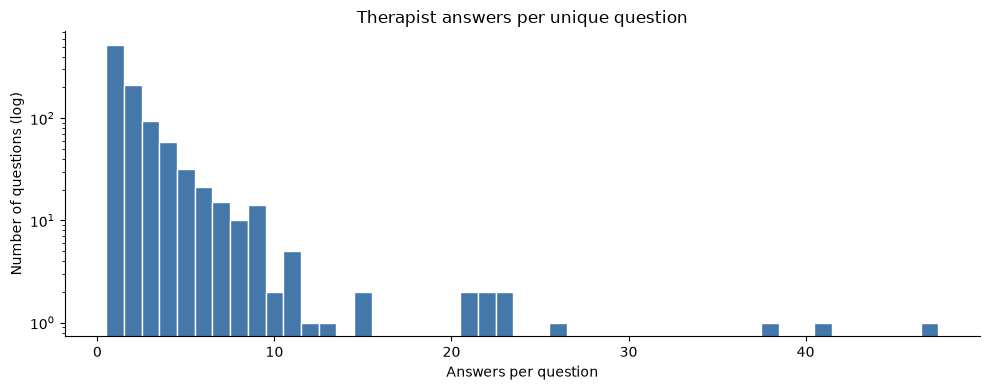

In [3]:
# Cell 3 — How many therapist answers does each question have?
answers_per_q = df["input"].value_counts()
print(f"Questions with a single answer: {(answers_per_q == 1).sum()}")
print(f"Max answers for one question:   {answers_per_q.max()}")
print(f"Mean answers per question:      {answers_per_q.mean():.2f}")

plt.figure(figsize=(10, 4))
plt.hist(answers_per_q.values, bins=np.arange(1, answers_per_q.max() + 2) - 0.5,
         color=C_INPUT, edgecolor="white")
plt.yscale("log")
plt.title("Therapist answers per unique question")
plt.xlabel("Answers per question")
plt.ylabel("Number of questions (log)")
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — Sample rows
for i, row in df[["input", "output"]].head(3).iterrows():
    print(f"--- Sample {i + 1} ---")
    print(f"INPUT:  {row['input'][:300]}...")
    print(f"OUTPUT: {row['output'][:300]}...")
    print()

--- Sample 1 ---
INPUT:  I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.
   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.
   How can I change my feeling of ...
OUTPUT: If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and...

--- Sample 2 ---
INPUT:  I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.
   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.
   How can I change my feeling of ...
OUTPUT: Hello, and thank you 

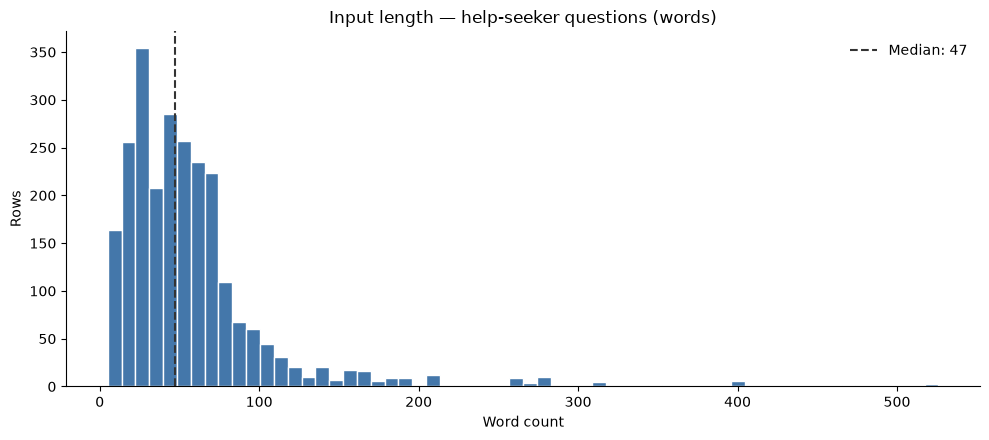

In [5]:
# Cell 5 — Input length distribution (word count)
df["input_words"] = df["input"].str.split().str.len()

plt.figure(figsize=(10, 4.5))
plt.hist(df["input_words"], bins=60, color=C_INPUT, edgecolor="white")
med = df["input_words"].median()
plt.axvline(med, color=C_MEDIAN, linestyle="--", label=f"Median: {med:.0f}")
plt.title("Input length — help-seeker questions (words)")
plt.xlabel("Word count")
plt.ylabel("Rows")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

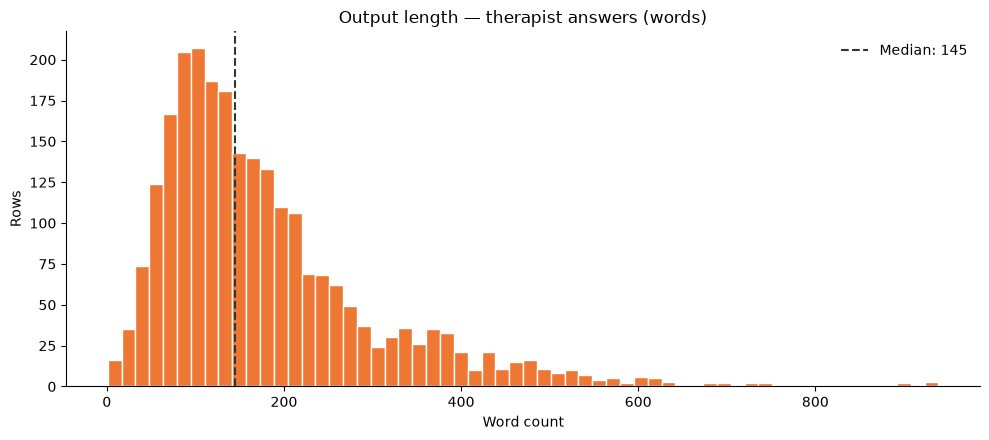

In [6]:
# Cell 6 — Output length distribution (word count)
df["output_words"] = df["output"].str.split().str.len()

plt.figure(figsize=(10, 4.5))
plt.hist(df["output_words"], bins=60, color=C_OUTPUT, edgecolor="white")
med = df["output_words"].median()
plt.axvline(med, color=C_MEDIAN, linestyle="--", label=f"Median: {med:.0f}")
plt.title("Output length — therapist answers (words)")
plt.xlabel("Word count")
plt.ylabel("Rows")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

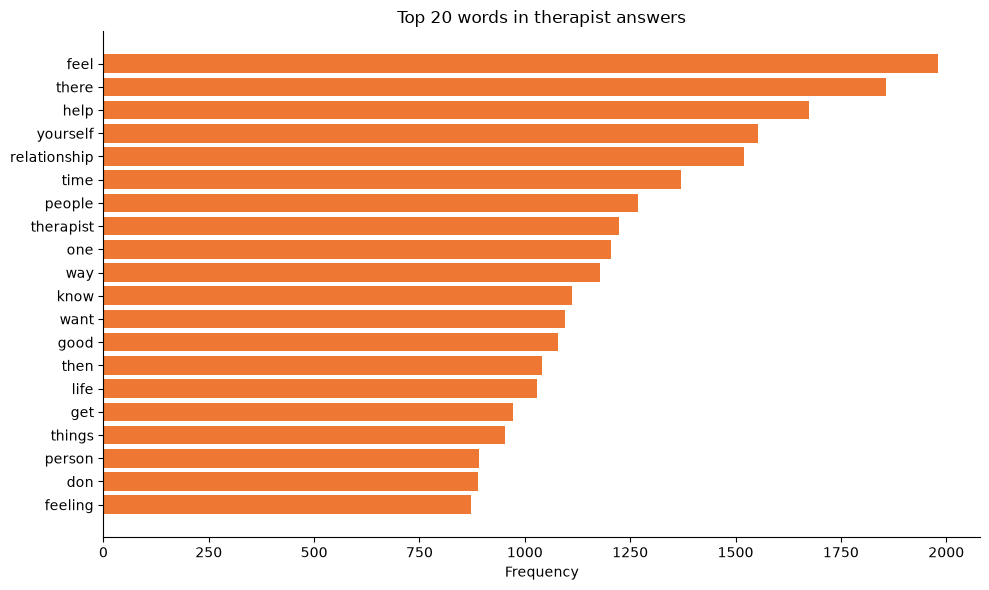

In [7]:
stopwords = {"the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
             "have", "has", "had", "do", "does", "did", "will", "would", "could",
             "should", "may", "might", "shall", "can", "need", "dare", "to", "of",
             "in", "for", "on", "with", "at", "by", "from", "as", "into", "through",
             "during", "before", "after", "and", "but", "or", "nor", "not", "so",
             "yet", "both", "either", "neither", "each", "every", "all", "any",
             "few", "more", "most", "other", "some", "such", "no", "only", "own",
             "same", "than", "too", "very", "just", "because", "if", "when", "where",
             "how", "what", "which", "who", "whom", "this", "that", "these", "those",
             "i", "me", "my", "myself", "we", "our", "ours", "you", "your", "yours",
             "he", "him", "his", "she", "her", "hers", "it", "its", "they", "them",
             "their", "theirs", "about", "up", "out", "also", "like", "well", "even"}

# Cell 7 — Top 20 words in therapist answers (excl. stopwords)
words = []
for text in df["output"]:
    words.extend(w for w in re.findall(r"[a-z]+", text.lower())
                 if w not in stopwords and len(w) > 2)
top20 = Counter(words).most_common(20)
labels, counts = zip(*top20)

plt.figure(figsize=(10, 6))
plt.barh(list(reversed(labels)), list(reversed(counts)), color=C_OUTPUT)
plt.title("Top 20 words in therapist answers")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 — Token statistics vs the 1024-token training window
enc = tiktoken.get_encoding("cl100k_base")  # approximation; the real tokenizers differ slightly
in_tok = df["input"].map(lambda t: len(enc.encode(t)))
out_tok = df["output"].map(lambda t: len(enc.encode(t)))
sys_tok = len(enc.encode(ft_utils.SYSTEM_PROMPT))
total = in_tok + out_tok + sys_tok + 20  # +20 ~ chat-template scaffolding

max_len = ft_utils.CFG["training"]["max_seq_length"]
print(f"Input tokens:  mean {in_tok.mean():.0f} | median {in_tok.median():.0f} | max {in_tok.max()}")
print(f"Output tokens: mean {out_tok.mean():.0f} | median {out_tok.median():.0f} | max {out_tok.max()}")
print(f"Full example (system+input+output+template): median {total.median():.0f} | "
      f"p95 {total.quantile(0.95):.0f} | max {total.max()}")
print(f"Examples fitting in max_seq_length={max_len}: {(total <= max_len).mean() * 100:.1f}%")

Input tokens:  mean 68 | median 55 | max 635
Output tokens: mean 233 | median 172 | max 22943
Full example (system+input+output+template): median 312 | p95 698 | max 23046
Examples fitting in max_seq_length=1024: 99.6%


In [9]:
# Cell 9 — Grouped 70/20/10 split (cached to data/.../processed/amod/)
train_df, val_df, test_df = ft_utils.load_and_split(DKEY)
n = len(train_df) + len(val_df) + len(test_df)
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(part):5,} rows ({len(part) / n * 100:.1f}%) | "
          f"unique questions: {part['input'].nunique():,}")

tr, va, te = set(train_df["input"]), set(val_df["input"]), set(test_df["input"])
print(f"\nLeakage check — shared questions across splits: "
      f"train-val={len(tr & va)}, train-test={len(tr & te)}, val-test={len(va & te)}")
assert not (tr & va) and not (tr & te) and not (va & te), "user-text leakage across splits!"
print("OK: no question appears in more than one split.")

[amod] saved splits -> C:\Users\laoli\OneDrive\Desktop\MultiAgent2\data\mh_conversation\processed\amod (train 1727, val 496, test 244)
train: 1,727 rows (70.0%) | unique questions: 747
val  :   496 rows (20.1%) | unique questions: 177
test :   244 rows (9.9%) | unique questions: 71

Leakage check — shared questions across splits: train-val=0, train-test=0, val-test=0
OK: no question appears in more than one split.


## Summary

| Metric | Value |
|---|---|
| Raw rows | 3,512 |
| Unique questions | 995 (max 94 answers for one question) |
| Cleaned rows | *(see Cell 2)* |
| Split | 70/20/10 **grouped by question**, seed 42 |

**Observations**

1. This is a one-question → many-answers dataset: ~3.5K rows collapse onto only 995 unique questions, so a row-level split would put the *same question* in train and test. The grouped split (Cell 9) removes that leakage entirely.
2. Questions are short; therapist answers are several times longer — the model learns long, structured counseling replies from short prompts.
3. Cell 8 shows what share of full formatted examples fits in the 1024-token training window; the remainder is handled by the trainer's packing/truncation.
4. The processed splits are cached under `data/mh_conversation/processed/amod/` and reused verbatim by `train.ipynb` (crisis examples are injected into train at training time, never stored in these files).